## makemore4
#### https://github.com/karpathy/makemore
#### 批量归一化

In [52]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import random
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [53]:
words = open('names.txt','r').read().splitlines()
len(words)

32033

In [54]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [55]:
# build the dataset
def build_dataset(words):
    block_size = 3
    X,Y = [],[]
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            idx = stoi[ch]
            X.append(context)
            Y.append(idx)
            context = context[1:] + [idx]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape,Y.shape)
    return X,Y

In [56]:
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,Ytr = build_dataset(words[:n1])
Xdev,Ydev = build_dataset(words[n1:n2])
Xte,Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


tensor(-0.0184) tensor(1.0044)
tensor(-0.0017) tensor(0.9821)


(array([2.25246273e-05, 2.25246273e-05, 1.12623136e-04, 1.12623136e-04,
        4.05443291e-04, 5.40591055e-04, 7.65837328e-04, 1.41905152e-03,
        2.45518437e-03, 3.82918664e-03, 5.90145235e-03, 9.82073750e-03,
        1.63303548e-02, 2.40788266e-02, 3.80891447e-02, 5.75729474e-02,
        8.14715769e-02, 1.19222852e-01, 1.68213917e-01, 2.17362653e-01,
        2.83810304e-01, 3.44559224e-01, 3.97379475e-01, 4.41640367e-01,
        4.38779740e-01, 4.11412317e-01, 3.55506193e-01, 2.97212457e-01,
        2.29931395e-01, 1.74273041e-01, 1.24313418e-01, 9.04363786e-02,
        5.90595728e-02, 3.97109179e-02, 2.65340109e-02, 1.51365495e-02,
        1.12397890e-02, 6.73486356e-03, 3.55889111e-03, 2.59033214e-03,
        1.14875599e-03, 9.46034346e-04, 5.18066428e-04, 4.05443291e-04,
        1.80197018e-04, 1.35147764e-04, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 2.25246273e-05]),
 array([-5.34628534, -5.12430609, -4.90232683, -4.68034758, -4.45836832,
        -4.23638906, 

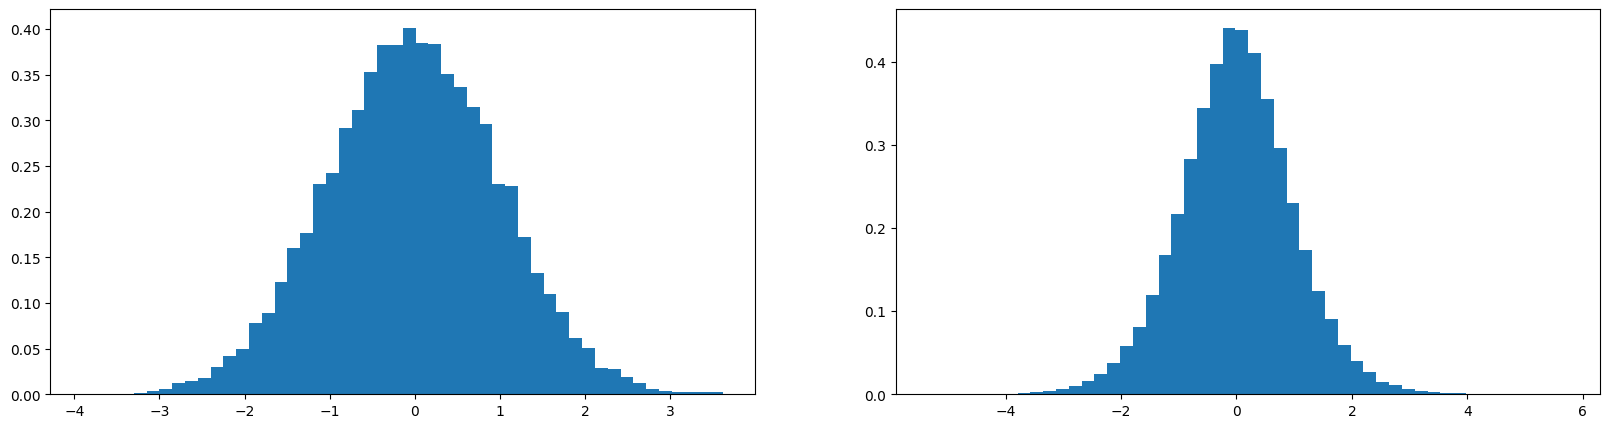

In [51]:
import torch
import matplotlib.pyplot as plt

# 输入张量：1000个样本，每个样本10维
x = torch.randn(1000, 10)
# 权重矩阵：10→200维，用0.2缩放
w = torch.randn(10, 200) / 10 ** 0.5
# 线性变换
y = x @ w

# 打印输入和输出的均值、标准差
print(x.mean(), x.std())
print(y.mean(), y.std())

# 绘制输入和输出的分布直方图
plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True)
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True)



In [ ]:
n_embd = 10
n_hidden = 200
block_size = 3

g = torch.Generator().manual_seed(42)
C = torch.randn((vocab_size,n_embd),generator=g)
W1 = torch.randn((n_embd*block_size,n_hidden),generator=g) * (5/3)/(n_embd*block_size)**0.5
b1 = torch.randn(n_hidden,generator=g) * 0.01
W2 = torch.randn((n_hidden,vocab_size),generator=g) *0.01
b2 = torch.randn(vocab_size,generator=g) * 0

bngain = torch.ones((1,n_hidden))
bnbias = torch.zeros((1,n_hidden))
bnmean_running = torch.zeros((1,n_hidden))
bnstd_running = torch.ones((1,n_hidden))

parameters = [C,W1,b1,W2,b2,bngain,bnbias]
sum(p.nelement() for p in parameters)

for p in parameters:
    p.requires_grad = True

In [82]:
max_steps = 20000
batch_size = 32
lossi = []

for i in range(max_steps):

    ix = torch.randint(0,Xtr.shape[0],(batch_size,),generator = g)
    Xb,Yb = Xtr[ix],Ytr[ix]

    # 向前传播
    emb = C[Xb]
    embcat = emb.view(emb.shape[0],-1)
    hpreact = embcat @ W1 # + b1
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias

    with torch.no_grad():
        bnmean_running = 0.999*bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999*bnstd_running + 0.001 * bnstdi
    
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits,Ytr[ix])

    # 向后传播
    for p in parameters:
        p.grad = None
    loss.backward()

    # 更新
    lr = 0.1 if i < 10000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    # 记录
    if i % 1000 == 0:
        print(f'{i:7d}/{max_steps:7d}:{loss.item():.4f}')
    lossi.append(loss.log10().item())
    # break

      0/  20000:3.3232
   1000/  20000:2.2140
   2000/  20000:2.2024
   3000/  20000:2.2735
   4000/  20000:2.1338
   5000/  20000:2.3227
   6000/  20000:2.4192
   7000/  20000:2.3135
   8000/  20000:2.4385
   9000/  20000:2.1922
  10000/  20000:1.8634
  11000/  20000:2.2028
  12000/  20000:1.8112
  13000/  20000:2.0319
  14000/  20000:1.8656
  15000/  20000:2.4927
  16000/  20000:2.3653
  17000/  20000:1.8862
  18000/  20000:2.1197
  19000/  20000:2.2553


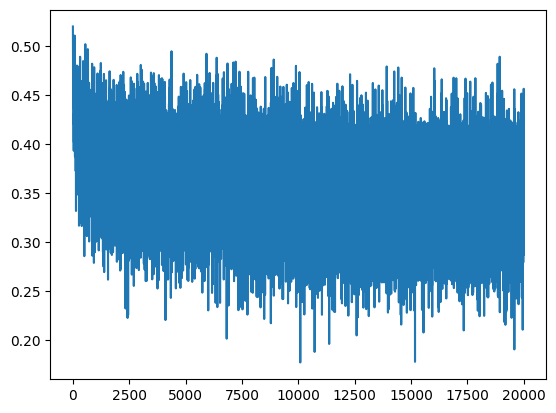

In [74]:
plt.plot(lossi)
# plt.figure(figsize=(20,10))
# plt.imshow(h.abs() > 0.99,cmap = 'gray',interpolation='nearest')
# plt.hist(h.view(-1).tolist(),50);

In [ ]:
# # calibrate the batch norm at the end of training
# with torch.no_grad():
#     # pass the training set through
#     emb = C[Xtr]
#     embcat = emb.view(emb.shape[0], -1)
#     hpreact = embcat @ W1 + b1
#     # measure the mean/std over the entire training set
#     bnmean = hpreact.mean(0, keepdim=True)
#     bnstd = hpreact.std(0, keepdim=True)

In [84]:
# 计算结果
@torch.no_grad()  # this decorator disables gradient tracking
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x]  # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1)  # concat into (N, block_size * n_embd)
    hpreact = embcat @ W1 + b1
    # hpreact = bngain * (hpreact - hpreact.mean(0,keepdim=True)) / hpreact.std(0,keepdim=True) + bnbias
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    # h = torch.tanh(embcat @ W1 + b1)  # (N, n_hidden)
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2  # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.1893117427825928
val 2.1984148025512695


In [ ]:
# 采样器
g = torch.Generator().manual_seed(42)

for _ in range(10):
    
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1,-1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits,dim=1)
        ix = torch.multinomial(probs,num_samples=1,generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print("".join(itos[i] for i in out))